# Motif contributions across cell states and differentiation paths

This notebook quantifies how much the motifs discovered in each cell state contribute to predicted accessibility in all cell states, and summarizes these contributions along each path of the differentiation trajectory.

Steps:
1. Load the matches of the top motifs of each cell state, and annotate them with their motif cluster.
2. Compute the contribution of each match in all cell states, i.e. the sum of the actual contributions of the bases in the match.
3. For each differentiation path, summarize contributions per motif and per motif cluster, using matches of motifs discovered in the path's cell states.
4. Plot summaries as heatmaps and on the differentiation trajectory, and plot the consensus PWM of each motif cluster.

Requirements:
- Contribution scores (`data/contributions/contributions.h5`), downloaded with `analysis/contributions/download_contributions.py`.
- Motif matches of each cell state (`analysis/motifs/find_motifs.py`) and motif clusters (`analysis/motifs/cluster_motifs.py`), or their precomputed versions downloaded with `analysis/motifs/download_motifs.py`.

## Imports

In [1]:
from pathlib import Path

import h5py
import numpy
import pandas
import scipy.cluster.hierarchy
import seaborn
from matplotlib import pyplot

from deepdanio import definitions, motif, plot

## Settings

- `N_PATTERNS`: number of positive TF-MoDISco patterns used from each cell state. Patterns are numbered by decreasing number of seqlets, so the first ones are the most frequent.
- `QUANTILE`: quantile of match contributions summarized in addition to the mean.
- `PATHS_FOR_TRAJECTORY_PLOTS`: differentiation paths for which the contributions of each motif cluster are plotted on the differentiation trajectory.
- `RESULTS_DIR`: output directory for tables and figures. `MATCH_CONTRIBUTIONS_PATH`: file where match contributions are cached.

In [2]:
N_PATTERNS = 5
QUANTILE = 0.9
PATHS_FOR_TRAJECTORY_PLOTS = ['ysl']
RESULTS_DIR = Path('results')
MATCH_CONTRIBUTIONS_PATH = Path('match_contributions.h5')

## Load motif matches

Matches of the first `N_PATTERNS` positive patterns of each cell state, found in the peaks selected in that cell state. Each motif is labeled as `'{cell state} {pattern index} (c{cluster index}.{cluster name})'`. Clusters without annotation are named by their ID.

In [3]:
motif_ids = [f'pos_patterns_pattern_{pattern_idx}' for pattern_idx in range(N_PATTERNS)]
match_dfs = []
for cell_state_idx, cell_state in enumerate(definitions.CELL_STATES):
    cell_state_dir = definitions.MOTIFS_DIR / definitions.MOTIFS_CELL_STATE_DIR_NAME.format(cell_state_idx=cell_state_idx)
    cell_state_match_df = pandas.read_csv(cell_state_dir / definitions.MOTIF_MATCHES_NAME, sep='\t')
    cell_state_match_df = cell_state_match_df[cell_state_match_df['motif'].isin(motif_ids)]
    cell_state_match_df.insert(0, 'motif_cell_state', cell_state)
    match_dfs.append(cell_state_match_df)
match_df = pandas.concat(match_dfs, ignore_index=True)

# Motif clusters and their names
motif_clusters_df = pandas.read_csv(definitions.MOTIF_CLUSTERS_PATH, sep='\t')
cluster_names = pandas.read_csv(definitions.MOTIF_CLUSTER_NAMES_PATH, sep='\t', index_col='cluster')['name']
unannotated = cluster_names == 'Can’t annotate'
cluster_names[unannotated] = cluster_names.index[unannotated]
match_df = match_df.merge(
    motif_clusters_df.rename(columns={'cell_state': 'motif_cell_state'}),
    on=['motif_cell_state', 'motif'],
    how='left',
)
assert match_df['cluster'].notna().all()
match_df['cluster_name'] = match_df['cluster'].map(cluster_names)
match_df['motif_label'] = (
    match_df['motif_cell_state'] + ' ' + match_df['motif'].str.split('_').str[-1]
    + ' (c' + match_df['cluster'].str.split('_').str[-1].str.lstrip('0') + '.' + match_df['cluster_name'] + ')'
)

print(f"{len(match_df):,} matches of {match_df['motif_label'].nunique()} motifs in {match_df['cluster'].nunique()} clusters.")
match_df.head()

2,048,610 matches of 475 motifs in 69 clusters.


,motif_cell_state,motif,peak_id,start,end,revcomp,cwm_contrib,cwm_match,pwm_prob,cluster,cluster_name,motif_label
0,high cells,pos_patterns_pattern_0,19-263622-264122,39,56,False,0.122105,0.527681,0.561988,cluster_078,klf17(1),high cells 0 (c78.klf17(1))
1,high cells,pos_patterns_pattern_0,19-263622-264122,76,93,False,0.149934,0.571467,0.601140,cluster_078,klf17(1),high cells 0 (c78.klf17(1))
2,high cells,pos_patterns_pattern_0,11-197905-198405,206,223,False,0.117534,0.580527,0.600377,cluster_078,klf17(1),high cells 0 (c78.klf17(1))
3,high cells,pos_patterns_pattern_0,11-197905-198405,283,300,False,0.116526,0.548590,0.600377,cluster_078,klf17(1),high cells 0 (c78.klf17(1))
4,high cells,pos_patterns_pattern_0,4-77362933-77363433,92,109,False,0.145343,0.655119,0.665644,cluster_078,klf17(1),high cells 0 (c78.klf17(1))


## Contributions of each match in all cell states

The contribution of a match in a cell state is the sum of the actual contributions of its bases. Contributions of all matches are computed by reading the contributions file in blocks of peaks, using cumulative sums along each peak. Results are cached in `MATCH_CONTRIBUTIONS_PATH`, together with the matches they correspond to, and recomputed if matches change.

In [4]:
match_key_cols = ['motif_cell_state', 'motif', 'peak_id', 'start', 'end']

# Load cached contributions if they correspond to the current matches
match_contribs = None
if MATCH_CONTRIBUTIONS_PATH.exists():
    with h5py.File(MATCH_CONTRIBUTIONS_PATH, 'r') as f:
        cached_keys = {col: f[col].asstr()[:] if f[col].dtype.kind == 'O' else f[col][:] for col in match_key_cols}
        if all(numpy.array_equal(cached_keys[col], match_df[col].to_numpy()) for col in match_key_cols):
            match_contribs = f['contributions'][:]
            print(f"Loaded match contributions from {MATCH_CONTRIBUTIONS_PATH}.")

if match_contribs is None:
    print("Computing match contributions...")
    match_contribs = numpy.empty((len(match_df), len(definitions.CELL_STATES)), dtype='float32')
    block_size = 2000
    with h5py.File(definitions.CONTRIBUTIONS_PATH, 'r') as f:
        contrib_dataset = f['contributions']
        match_peak_idx = pandas.Index(f['peak_id'].asstr()[:]).get_indexer(match_df['peak_id'])
        match_order = numpy.argsort(match_peak_idx, kind='stable')
        sorted_peak_idx = match_peak_idx[match_order]
        for block_start in range(0, contrib_dataset.shape[0], block_size):
            block_end = min(block_start + block_size, contrib_dataset.shape[0])
            # Matches in peaks of this block
            first, last = numpy.searchsorted(sorted_peak_idx, [block_start, block_end])
            block_matches = match_order[first:last]
            if len(block_matches) == 0:
                continue
            # Cumulative contributions with shape (n_block_peaks, n_cell_states, seq_length + 1)
            cumsum = numpy.zeros((block_end - block_start, contrib_dataset.shape[1], contrib_dataset.shape[2] + 1))
            numpy.cumsum(contrib_dataset[block_start:block_end], axis=2, dtype='float64', out=cumsum[:, :, 1:])
            block_peak_idx = match_peak_idx[block_matches] - block_start
            match_contribs[block_matches] = (
                cumsum[block_peak_idx, :, match_df['end'].values[block_matches]]
                - cumsum[block_peak_idx, :, match_df['start'].values[block_matches]]
            )

    with h5py.File(MATCH_CONTRIBUTIONS_PATH, 'w') as f:
        for col in match_key_cols:
            if pandas.api.types.is_integer_dtype(match_df[col]):
                f.create_dataset(col, data=match_df[col].to_numpy())
            else:
                f.create_dataset(col, data=match_df[col].tolist(), dtype=h5py.string_dtype())
        f.create_dataset('contributions', data=match_contribs, compression='gzip')
    print(f"Saved match contributions to {MATCH_CONTRIBUTIONS_PATH}.")

match_contrib_df = pandas.DataFrame(match_contribs, columns=definitions.CELL_STATES)

Computing match contributions...


Saved match contributions to match_contributions.h5.


## Contribution summaries per differentiation path

For each differentiation path, matches of motifs discovered in any cell state of the path are summarized by their mean and their `QUANTILE` quantile of contributions in all cell states, per motif and per motif cluster. Tables are saved in one directory per path, with motifs or clusters as rows and all cell states as columns.

In [5]:
path_summaries = {}
for path_name, path_cell_states in definitions.DIFFERENTIATION_PATHS.items():
    in_path = match_df['motif_cell_state'].isin(path_cell_states).values
    path_contrib_df = match_contrib_df[in_path]
    path_summaries[path_name] = {
        'motif_mean': path_contrib_df.groupby(match_df.loc[in_path, 'motif_label'].values).mean(),
        'motif_quantile': path_contrib_df.groupby(match_df.loc[in_path, 'motif_label'].values).quantile(QUANTILE),
        'cluster_mean': path_contrib_df.groupby(match_df.loc[in_path, 'cluster_name'].values).mean(),
        'cluster_quantile': path_contrib_df.groupby(match_df.loc[in_path, 'cluster_name'].values).quantile(QUANTILE),
    }

    path_dir = RESULTS_DIR / path_name.replace('/', '_').replace(' ', '_')
    path_dir.mkdir(parents=True, exist_ok=True)
    for summary_name, summary_df in path_summaries[path_name].items():
        summary_df.to_csv(path_dir / f'{summary_name}.tsv', sep='\t')

print(f"Saved summaries of {len(path_summaries)} paths to {RESULTS_DIR}.")

Saved summaries of 29 paths to results.


## Heatmaps

Heatmaps show summaries in the cell states of each path, with rows ordered by hierarchical clustering. They are saved for every path and summary, both raw and normalized to the maximum absolute value of each row, which highlights where along the path each motif contributes the most. The cell below shows the mean contribution of motif clusters along one path.

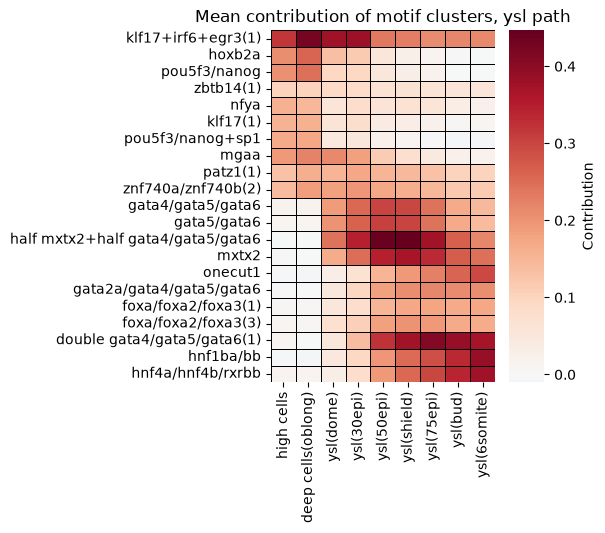

In [6]:
def plot_contrib_heatmap(summary_df):
    """Heatmap of contributions, with rows ordered by hierarchical clustering."""
    linkage = scipy.cluster.hierarchy.linkage(summary_df, method='average', metric='euclidean')
    summary_df = summary_df.iloc[scipy.cluster.hierarchy.leaves_list(linkage)]
    fig, ax = pyplot.subplots(figsize=(summary_df.shape[1] * 0.18 + 2, summary_df.shape[0] * 0.17 + 1))
    seaborn.heatmap(
        summary_df,
        cmap='RdBu_r',
        center=0,
        xticklabels=True,
        yticklabels=True,
        cbar_kws={'label': 'Contribution', 'aspect': 10},
        linewidths=0.5,
        linecolor='black',
        ax=ax,
    )
    return fig


for path_name, path_cell_states in definitions.DIFFERENTIATION_PATHS.items():
    path_dir = RESULTS_DIR / path_name.replace('/', '_').replace(' ', '_')
    for summary_name, summary_df in path_summaries[path_name].items():
        summary_df = summary_df[path_cell_states]
        normalized_df = summary_df.div(summary_df.abs().max(axis=1), axis=0)
        for df, suffix in [(summary_df, ''), (normalized_df, '_normalized')]:
            fig = plot_contrib_heatmap(df)
            fig.savefig(path_dir / f'{summary_name}{suffix}.png', dpi=200, bbox_inches='tight')
            pyplot.close(fig)

example_path = PATHS_FOR_TRAJECTORY_PLOTS[0]
fig = plot_contrib_heatmap(path_summaries[example_path]['cluster_mean'][definitions.DIFFERENTIATION_PATHS[example_path]])
fig.axes[0].set_title(f'Mean contribution of motif clusters, {example_path} path')
pyplot.show()

## Motif cluster contributions on the differentiation trajectory

For the paths in `PATHS_FOR_TRAJECTORY_PLOTS`, the mean contribution of each motif cluster in all cell states is plotted on the differentiation trajectory, and saved as one figure per cluster. The cell below shows the first cluster.

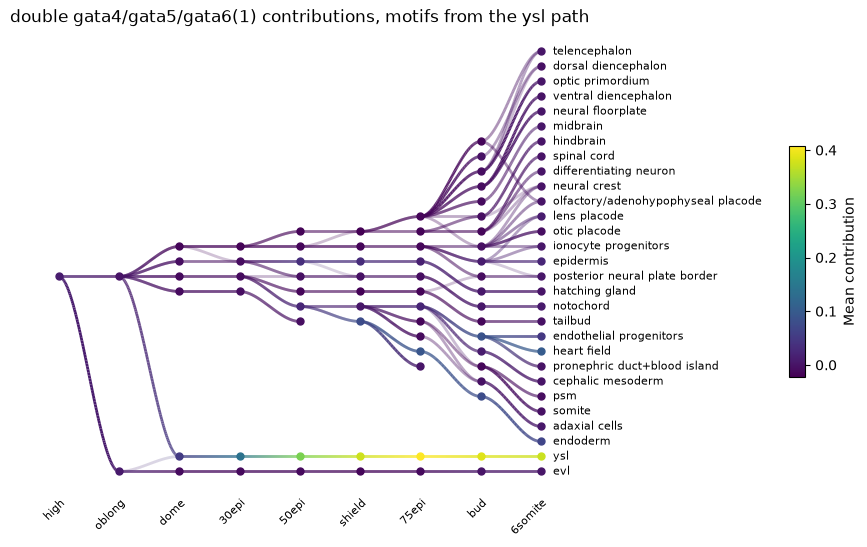

In [7]:
for path_name in PATHS_FOR_TRAJECTORY_PLOTS:
    trajectory_dir = RESULTS_DIR / path_name.replace('/', '_').replace(' ', '_') / 'cluster_mean_trajectories'
    trajectory_dir.mkdir(parents=True, exist_ok=True)
    for cluster_name, cluster_contribs in path_summaries[path_name]['cluster_mean'].iterrows():
        fig, ax = pyplot.subplots(figsize=(7, 6))
        plot.trajectory(cell_state_vals=cluster_contribs, colorbar=True, colorbar_label='Mean contribution', cell_state_labels='final', linewidth=2, ax=ax)
        ax.set_title(f'{cluster_name} contributions')
        fig.savefig(trajectory_dir / f"{cluster_name.replace('/', '_')}.svg", bbox_inches='tight')
        pyplot.close(fig)

cluster_name, cluster_contribs = next(path_summaries[PATHS_FOR_TRAJECTORY_PLOTS[0]]['cluster_mean'].iterrows())
fig, ax = pyplot.subplots(figsize=(7, 6))
plot.trajectory(cell_state_vals=cluster_contribs, colorbar=True, colorbar_label='Mean contribution', cell_state_labels='final', linewidth=2, ax=ax)
ax.set_title(f'{cluster_name} contributions, motifs from the {PATHS_FOR_TRAJECTORY_PLOTS[0]} path')
pyplot.show()

## Motif cluster logos

The consensus PWM of each motif cluster is saved as a sequence logo. The cell below shows the first clusters.

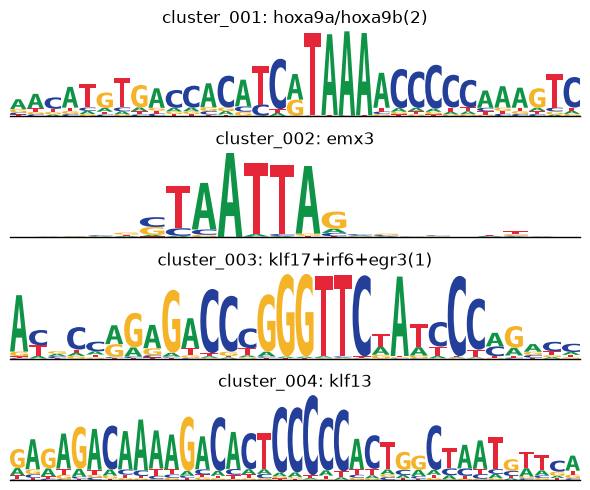

In [8]:
cluster_pwms = motif.load_meme(definitions.CLUSTER_PWMS_PATH)
logo_dir = RESULTS_DIR / 'cluster_logos'
logo_dir.mkdir(parents=True, exist_ok=True)
for cluster, pwm in cluster_pwms.items():
    fig, ax = pyplot.subplots(figsize=(len(pwm) * 0.2, 1))
    plot.sequence_logo(pwm=pwm, title=f'{cluster}: {cluster_names[cluster]}', ax=ax)
    fig.savefig(logo_dir / f'{cluster}.svg', bbox_inches='tight')
    pyplot.close(fig)

fig, axes = pyplot.subplots(4, 1, figsize=(6, 5))
for ax, (cluster, pwm) in zip(axes, list(cluster_pwms.items())[:4]):
    plot.sequence_logo(pwm=pwm, title=f'{cluster}: {cluster_names[cluster]}', ax=ax)
fig.tight_layout()
pyplot.show()